In [4]:
import argparse
import os
import sys
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
import traceback

warnings.filterwarnings("ignore")

from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import load_trials_and_mask

from communication_subspace.ibl_communication.utils import load_widefield_epoch, setup_logger
from communication_subspace.ibl_communication.crossvalidated_rrr import optimize_rrr_rank
from iblatlas.atlas import AllenAtlas
from iblatlas.regions import BrainRegions
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pickle as pkl
from glob import glob
import seaborn as sns
from manifold.widefield_ppi import return_labels
from manifold.plot_decoders import load_data, plot_crosstime, aggregate_crosstime, plot_prior, plot_prior_per_animal, aggregate_prior

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Plotting crosstime decoders...


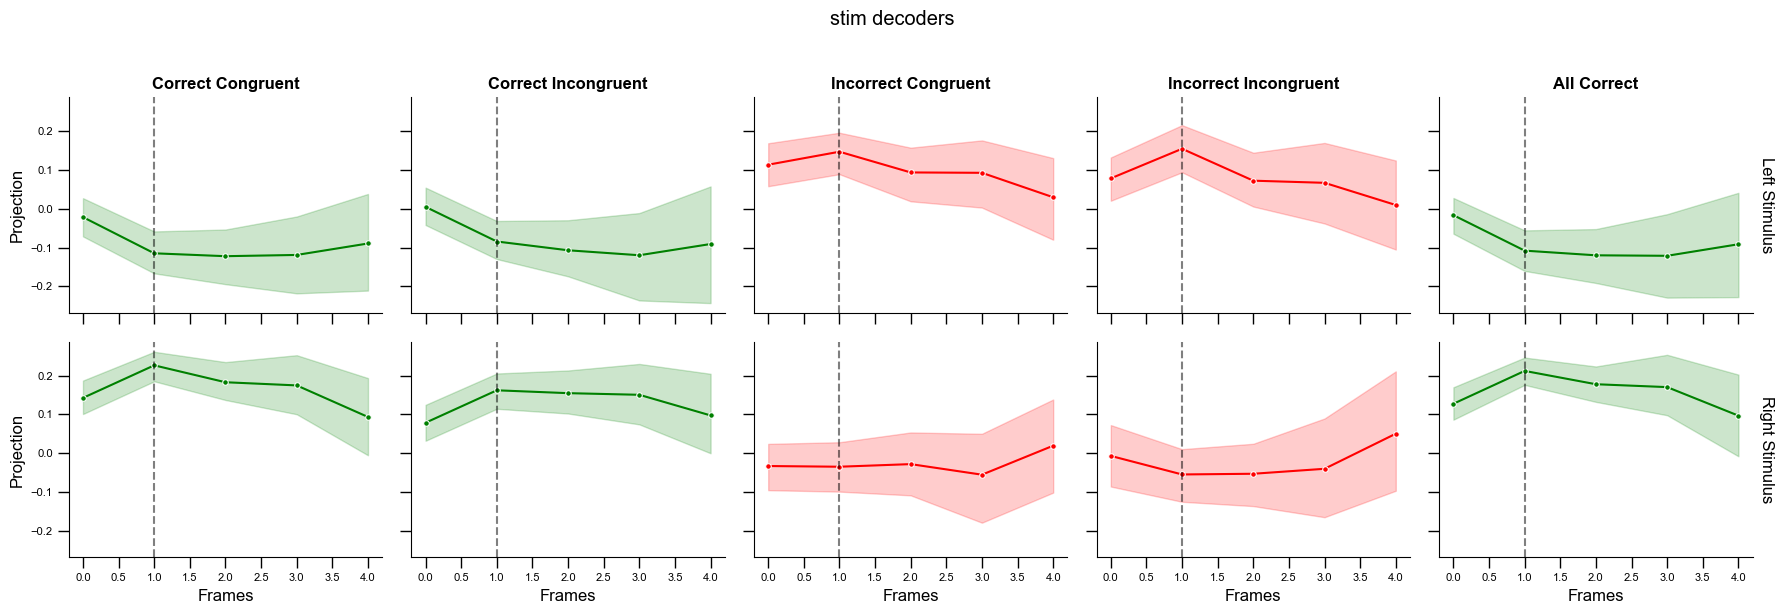

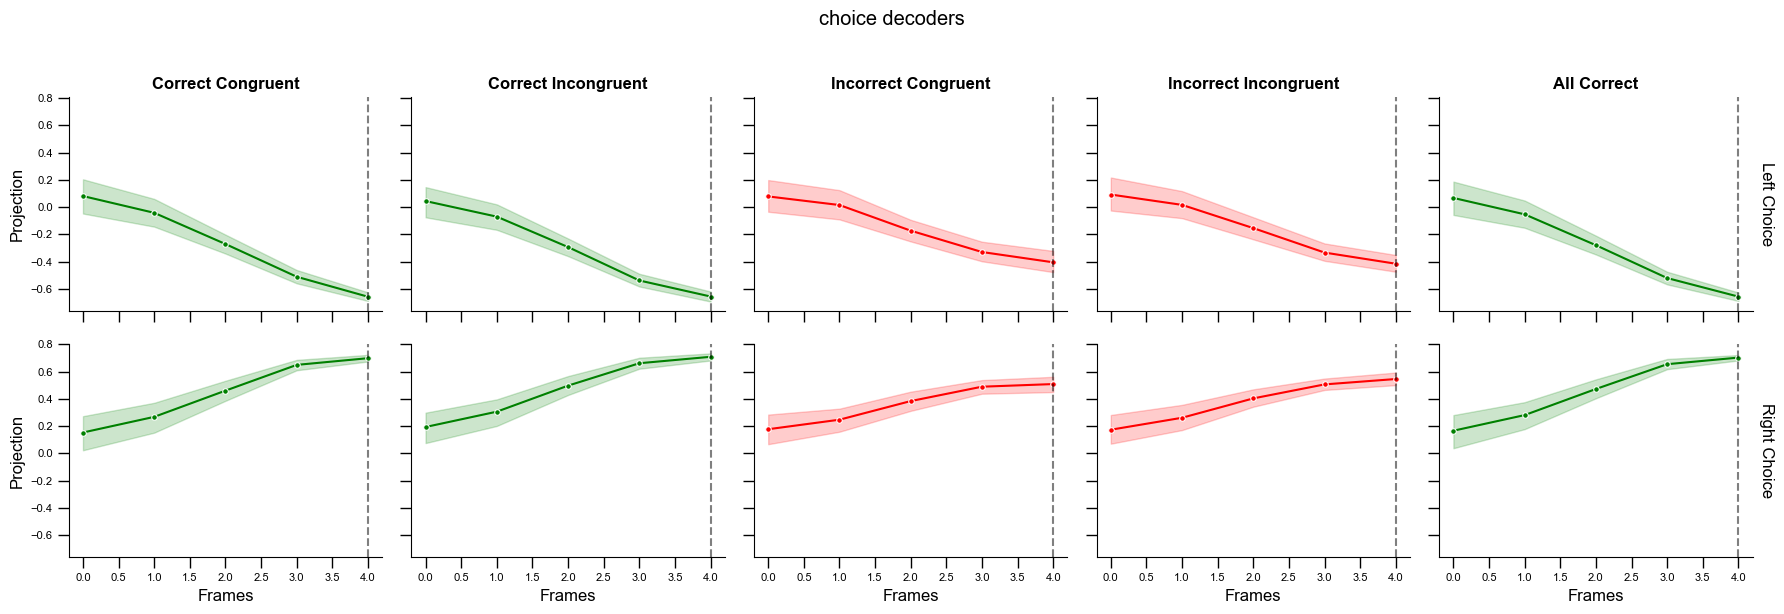

In [7]:
df_cross = load_data('../data/generated/crosstime_decoders/allcorrect_trained/*.pqt')
if not df_cross.empty:
    df_cross_melt = aggregate_crosstime(df_cross)
    print("Plotting crosstime decoders...")
    plot_crosstime(df_cross_melt)
else:
    print("No crosstime data found.")
    


In [22]:
stim_epoch = df_cross_melt[(df_cross_melt['model_epoch']=='stim') & df_cross_melt['is_correct_trial'] & (df_cross_melt['time']==1)]

In [40]:
counts = stim_epoch.groupby(['session_id','stim_side_computed']).size().unstack(fill_value=0)

In [41]:
counts['diff'] = counts[1.0] - counts[-1.0]
counts['frac_pos'] = counts[1.0] / (counts[1.0] + counts[-1.0])

Text(0, 0.5, 'Number of sessions')

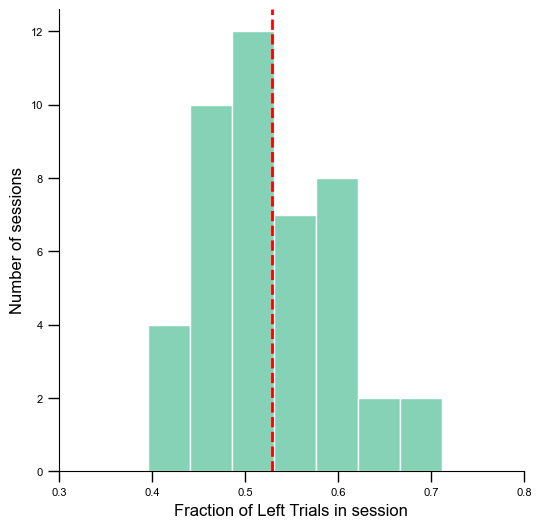

In [71]:
fig,ax = plt.subplots(figsize=(6,6))
sns.histplot(counts['frac_pos'],color="#0da66e",alpha=0.5, edgecolor='white')
ax.set_xlabel('Fraction of Left Trials in session')
ax.axvline(np.mean(counts['frac_pos']),color='red',linestyle='--',linewidth=2)
ax.set_xlim(0.3,0.8)
ax.set_ylabel('Number of sessions')